# LoanSense - Intelligent Loan Approval Predictor

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
# Load the Data
df = pd.read_csv("loan_approval_data.csv")

In [3]:
df.sample(5)
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

Applicant_ID          50
Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

## Handle Missing Values

In [4]:
categorical_cols = df.select_dtypes(include = ["object"]).columns
numerical_cols = df.select_dtypes(include = ["number"]).columns

In [5]:
from sklearn.impute import SimpleImputer 

cat_imp = SimpleImputer(strategy = "most_frequent")
df[categorical_cols] = cat_imp.fit_transform(df[categorical_cols])

In [6]:
num_imp = SimpleImputer(strategy = "mean")
df[numerical_cols] = num_imp.fit_transform(df[numerical_cols])

In [7]:
df.head()
df.isnull().sum()

Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

## EDA - Exploratory Data Analysis

Text(0.5, 1.0, 'Is Loan approved or not ?')

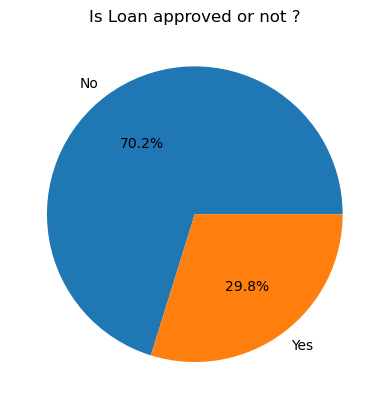

In [8]:
# How balanced our classes are ?

classes_cnt = df["Loan_Approved"].value_counts()

plt.pie(classes_cnt, labels = ["No", "Yes"], autopct = "%1.1f%%")
plt.title("Is Loan approved or not ?")

[Text(0, 0, '722'), Text(0, 0, '278')]

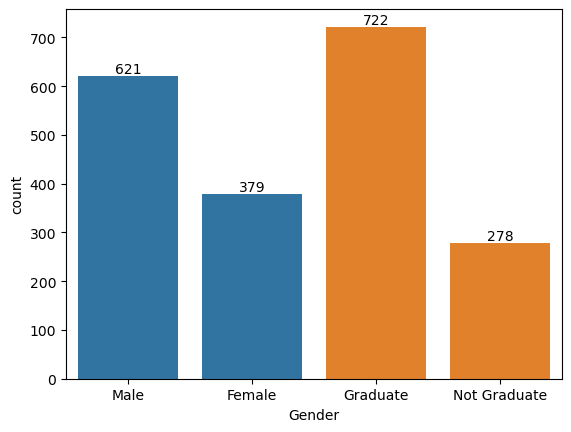

In [9]:
# Analyse Categories
gender_cnt = df["Gender"].value_counts()
ax = sns.barplot(gender_cnt)
ax.bar_label(ax.containers[0])

edu_cnt = df["Education_Level"].value_counts()
ax = sns.barplot(edu_cnt)
ax.bar_label(ax.containers[1])

<Axes: xlabel='Applicant_Income', ylabel='Count'>

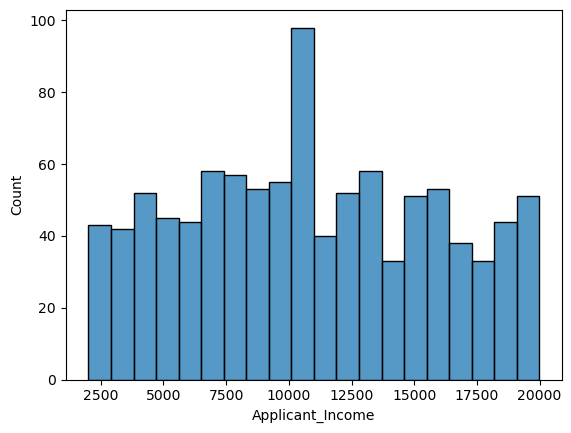

In [10]:
# Analyse Income
sns.histplot(
    data = df,
    x = "Applicant_Income",
    bins = 20
)

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

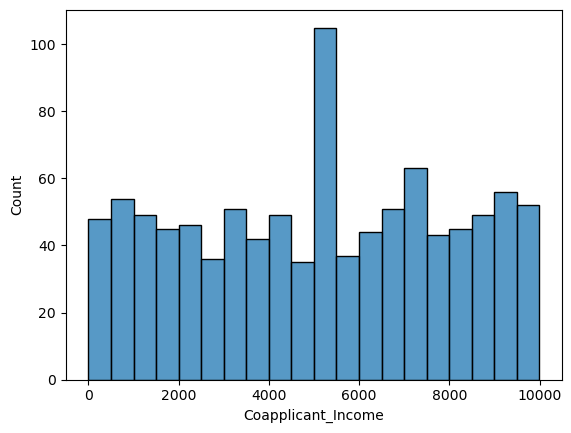

In [11]:
sns.histplot(
    data = df,
    x = "Coapplicant_Income",
    bins = 20
)

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

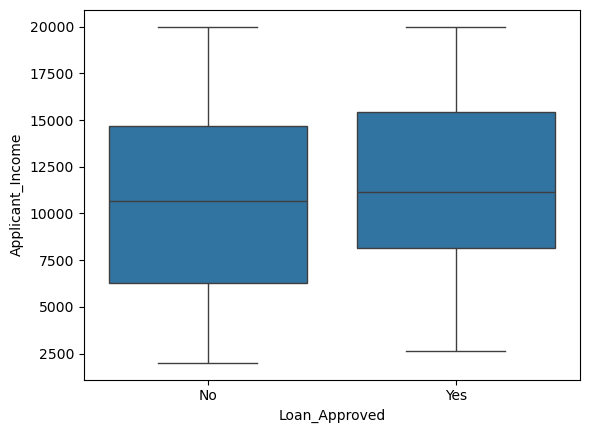

In [12]:
# For Outliers - Boxplots are beneficial.
sns.boxplot(
    data = df,
    x = "Loan_Approved",
    y = "Applicant_Income"
)

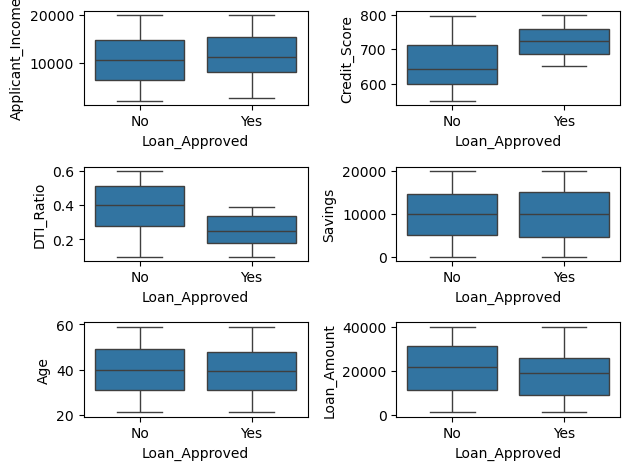

In [13]:
# Subplots
fig, axes = plt.subplots(3, 2)

sns.boxplot(ax = axes[0, 0], data = df, x = "Loan_Approved", y = "Applicant_Income")
sns.boxplot(ax = axes[0, 1], data = df, x = "Loan_Approved", y = "Credit_Score")
sns.boxplot(ax = axes[1, 0], data = df, x = "Loan_Approved", y = "DTI_Ratio")
sns.boxplot(ax = axes[1, 1], data = df, x = "Loan_Approved", y = "Savings")
sns.boxplot(ax = axes[2, 0], data = df, x = "Loan_Approved", y = "Age")
sns.boxplot(ax = axes[2, 1], data = df, x = "Loan_Approved", y = "Loan_Amount")

plt.tight_layout()

<Axes: xlabel='Credit_Score', ylabel='Count'>

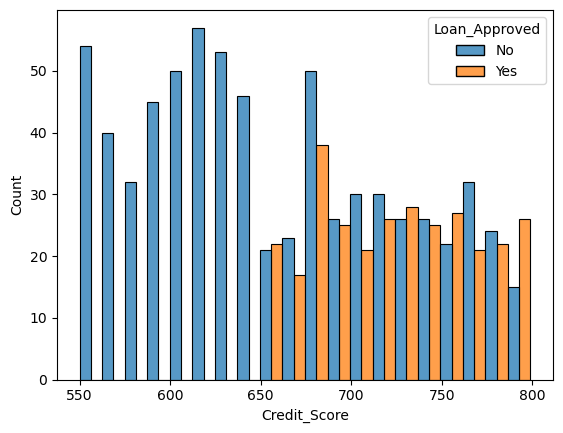

In [14]:
# Credit Score with Loan Approved
sns.histplot(
    data = df,
    x = "Credit_Score",
    hue = "Loan_Approved",
    bins = 20,
    multiple = "dodge"
)

# For Loan Approval ---> Credit Score >= 650

In [15]:
# Remove Applicant ID
df = df.drop("Applicant_ID", axis = 1)

In [16]:
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


## Feature Encoding

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_Income    1000 non-null   float64
 1   Coapplicant_Income  1000 non-null   float64
 2   Employment_Status   1000 non-null   object 
 3   Age                 1000 non-null   float64
 4   Marital_Status      1000 non-null   object 
 5   Dependents          1000 non-null   float64
 6   Credit_Score        1000 non-null   float64
 7   Existing_Loans      1000 non-null   float64
 8   DTI_Ratio           1000 non-null   float64
 9   Savings             1000 non-null   float64
 10  Collateral_Value    1000 non-null   float64
 11  Loan_Amount         1000 non-null   float64
 12  Loan_Term           1000 non-null   float64
 13  Loan_Purpose        1000 non-null   object 
 14  Property_Area       1000 non-null   object 
 15  Education_Level     1000 non-null   object 
 16  Gender 

In [18]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# Label Encoder - Categories Has Some Priority
le = LabelEncoder()
df["Education_Level"] = le.fit_transform(df["Education_Level"])
df["Loan_Approved"] = le.fit_transform(df["Loan_Approved"])

In [19]:
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,1,Female,Private,0
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,0,Male,Private,0
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,0,Female,Government,1
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,0,Female,Government,0
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,0,Male,Private,1


In [20]:
# One Hot Encoding - Every Category has same priority
cols = ["Employment_Status", "Marital_Status", "Loan_Purpose", "Property_Area", "Gender", "Employer_Category"]

ohe = OneHotEncoder(drop = "first", sparse_output = False, handle_unknown = "ignore")

encoded = ohe.fit_transform(df[cols])

encoded_df = pd.DataFrame(encoded, columns = ohe.get_feature_names_out(cols), index = df.index)

df = pd.concat([df.drop(columns = cols), encoded_df], axis = 1)

In [21]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_Income                 1000 non-null   float64
 1   Coapplicant_Income               1000 non-null   float64
 2   Age                              1000 non-null   float64
 3   Dependents                       1000 non-null   float64
 4   Credit_Score                     1000 non-null   float64
 5   Existing_Loans                   1000 non-null   float64
 6   DTI_Ratio                        1000 non-null   float64
 7   Savings                          1000 non-null   float64
 8   Collateral_Value                 1000 non-null   float64
 9   Loan_Amount                      1000 non-null   float64
 10  Loan_Term                        1000 non-null   float64
 11  Education_Level                  1000 non-null   int64  
 12  Loan_Approved        

## Correlation Heatmap

In [22]:
# Correlation Matrix

num_cols = df.select_dtypes(include = "number")
corr_matrix = num_cols.corr()
corr_matrix

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
Applicant_Income,1.000000,0.007545,-0.023988,-0.026658,-0.009818,-0.010457,-0.009107,-0.028358,0.018789,-0.024143,...,0.032794,0.074209,-0.031234,0.004845,-0.036260,-0.020871,-0.025011,0.102589,-0.044639,-0.011995
Coapplicant_Income,0.007545,1.000000,0.014306,-0.026733,0.058423,0.012418,0.058078,-0.015047,0.009457,0.001596,...,0.028000,0.016022,0.059549,-0.010058,0.030045,-0.010148,-0.001146,0.037640,0.004312,-0.047929
Age,-0.023988,0.014306,1.000000,-0.018767,-0.004212,0.023330,0.007903,-0.000986,0.037382,0.013502,...,-0.006283,0.029865,0.037293,0.003100,-0.025661,0.048402,-0.066041,0.021232,-0.012960,0.072462
Dependents,-0.026658,-0.026733,-0.018767,1.000000,-0.007687,-0.026338,0.011498,-0.004981,0.023004,-0.017409,...,-0.044642,0.027343,-0.005785,-0.032278,0.024082,0.013706,-0.009250,-0.018757,0.030197,-0.054147
Credit_Score,-0.009818,0.058423,-0.004212,-0.007687,1.000000,-0.007130,0.002338,-0.065353,0.007865,0.001002,...,0.026013,-0.008658,0.015324,-0.006946,0.004445,-0.039739,-0.007076,0.066736,-0.000049,-0.046087
Existing_Loans,-0.010457,0.012418,0.023330,-0.026338,-0.007130,1.000000,0.047008,0.034435,-0.049916,-0.021035,...,-0.010035,0.001777,0.023212,-0.053971,0.035629,-0.038762,-0.009642,0.030520,-0.019306,0.045391
DTI_Ratio,-0.009107,0.058078,0.007903,0.011498,0.002338,0.047008,1.000000,0.004663,-0.009622,0.075784,...,0.040432,-0.014125,-0.036648,0.044898,-0.006156,0.009624,-0.007214,0.002090,-0.003506,0.026018
Savings,-0.028358,-0.015047,-0.000986,-0.004981,-0.065353,0.034435,0.004663,1.000000,0.015481,-0.012208,...,0.032558,-0.012217,-0.028948,0.005438,0.016833,-0.006667,-0.011683,0.004381,-0.030208,0.027178
Collateral_Value,0.018789,0.009457,0.037382,0.023004,0.007865,-0.049916,-0.009622,0.015481,1.000000,0.002660,...,0.040406,-0.050975,-0.007120,0.020061,0.007975,0.000897,0.035760,-0.013464,-0.014480,-0.009655
Loan_Amount,-0.024143,0.001596,0.013502,-0.017409,0.001002,-0.021035,0.075784,-0.012208,0.002660,1.000000,...,-0.006119,-0.000930,0.032498,0.040206,-0.050076,0.103456,0.013108,-0.025975,0.013923,-0.026566


Text(0.5, 1.0, 'Correlation Heatmap')

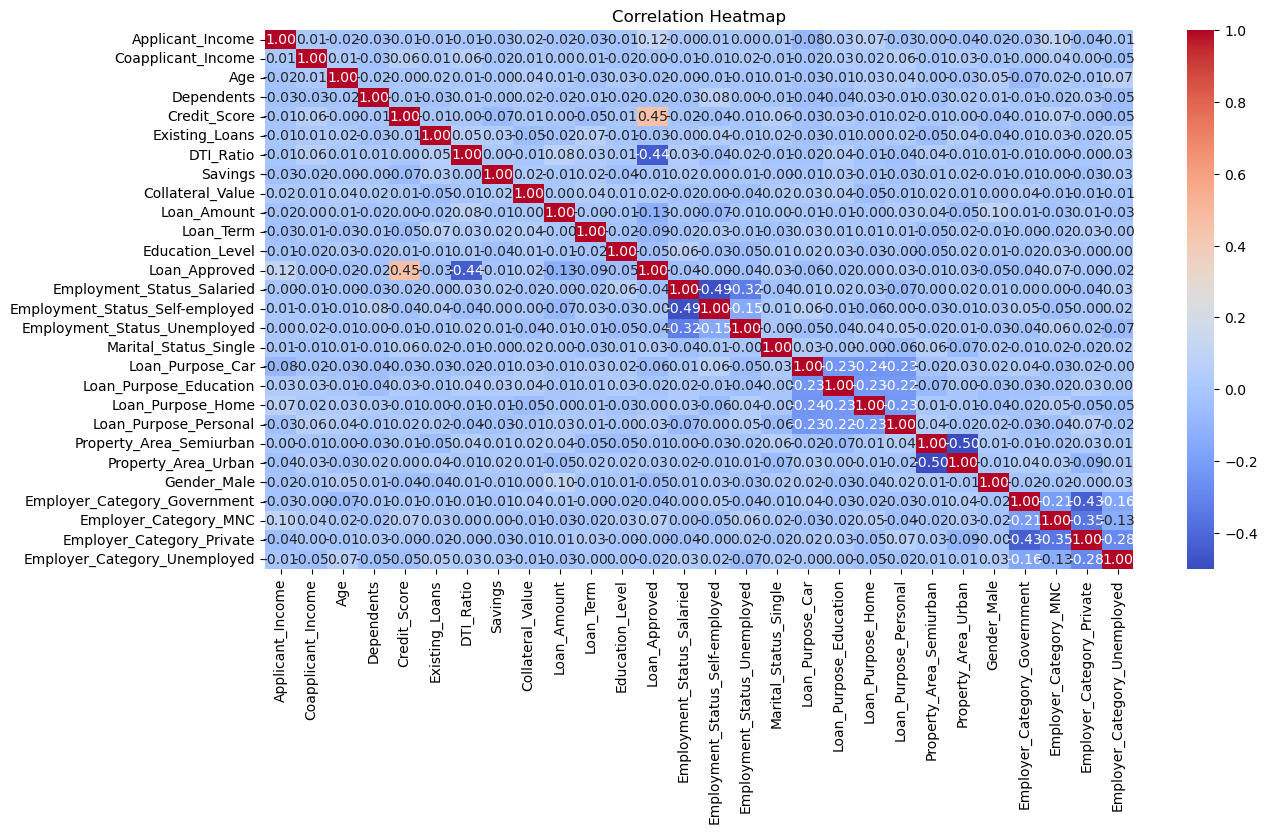

In [23]:
# Correlation Heatmap

plt.figure(figsize = (14, 7))
sns.heatmap(
    corr_matrix,
    annot = True,
    fmt = "0.2f",
    cmap = "coolwarm"
)

plt.title("Correlation Heatmap")

In [24]:
# Correlation of Every Cols with the Output

num_cols.corr()["Loan_Approved"].sort_values(ascending = False)

# So Credit_Score, Applicant_Income, DTI_Ratio, Loan_Amount are most imp features in the dataset.

Loan_Approved                      1.000000
Credit_Score                       0.451175
Applicant_Income                   0.119796
Employer_Category_MNC              0.069049
Loan_Purpose_Personal              0.034043
Marital_Status_Single              0.030182
Property_Area_Urban                0.025963
Collateral_Value                   0.021868
Coapplicant_Income                 0.004230
Loan_Purpose_Home                  0.002118
Employment_Status_Self-employed   -0.001337
Employer_Category_Private         -0.003347
Property_Area_Semiurban           -0.012967
Savings                           -0.013437
Loan_Purpose_Education            -0.016684
Employer_Category_Unemployed      -0.021468
Age                               -0.022343
Dependents                        -0.023811
Existing_Loans                    -0.034794
Employer_Category_Government      -0.039187
Employment_Status_Salaried        -0.041428
Employment_Status_Unemployed      -0.044464
Education_Level                 

## Feature Engineering

In [25]:
# Since from heatmap we know -> Credit_Score & DTI_Ratio are most important.

# We are squaring these features to make it more effective.
df["DTI_Ratio_sq"] = df["DTI_Ratio"] ** 2
df["Credit_Score_sq"] = df["Credit_Score"] ** 2

# Compressing any feature 
# df["Applicant_Income_log"] = np.log1p(df["Applicant_Income"])

## Train_Test_Split + Feature Scaling 

In [26]:
# Define Input-Output
X = df.drop(columns = ["Loan_Approved", "DTI_Ratio", "Credit_Score"])
y = df["Loan_Approved"]

In [27]:
X.head()

# Since we have a large no of columns, So we can say that KNN will not going to perform well.[Due to data sparse]

,Applicant_Income,Coapplicant_Income,Age,Dependents,Existing_Loans,Savings,Collateral_Value,Loan_Amount,Loan_Term,Education_Level,...,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed,DTI_Ratio_sq,Credit_Score_sq
0,17795.0,1387.0,51.0,0.0,4.0,19403.0,45638.0,16619.0,84.0,1,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.2809,405769.0
1,2860.0,2679.0,46.0,3.0,2.0,2580.0,49272.0,38687.0,48.0,0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0900,385641.0
2,7390.0,2106.0,25.0,2.0,4.0,13844.0,6908.0,27943.0,72.0,0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0400,454276.0
3,13964.0,8173.0,40.0,2.0,3.0,9553.0,10844.0,27819.0,60.0,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0961,335241.0
4,13284.0,4223.0,31.0,2.0,1.0,9386.0,37629.0,12741.0,72.0,0,...,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0841,519841.0


In [28]:
# Train Test Split 
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size = 0.2, random_state = 42)

In [29]:
X_test.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Existing_Loans,Savings,Collateral_Value,Loan_Amount,Loan_Term,Education_Level,...,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed,DTI_Ratio_sq,Credit_Score_sq
521,13023.0,6675.0,53.000000,3.0,3.0,10051.000000,26309.0,22947.000000,48.0,1,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.120592,394384.0
737,15917.0,6787.0,42.000000,0.0,4.0,922.000000,13476.0,20522.825263,60.0,0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.168100,345744.0
740,7560.0,3530.0,52.000000,3.0,0.0,9940.452632,21795.0,5876.000000,48.0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.336400,367236.0
660,19022.0,574.0,59.000000,0.0,4.0,1463.000000,44498.0,8433.000000,72.0,0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.168100,525625.0
411,4967.0,5797.0,39.971579,3.0,4.0,1095.000000,3017.0,33926.000000,36.0,1,...,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.336400,485809.0


In [30]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [31]:
X_train_scaled

array([[-1.01234556e+00,  1.02716377e+00, -8.22511453e-01, ...,
        -3.07231582e-01, -1.29156426e+00, -1.02979529e+00],
       [-1.23639141e+00, -1.59187898e+00,  9.15886794e-01, ...,
        -3.07231582e-01, -9.70501983e-01, -8.86224622e-01],
       [-1.15862490e-02,  1.33606578e+00, -3.65038230e-01, ...,
        -3.07231582e-01, -9.27359240e-01, -1.27166794e+00],
       ...,
       [-2.27277589e-01,  3.50089621e-01, -8.22511453e-01, ...,
        -3.07231582e-01, -2.03045749e-01,  3.70841797e-01],
       [ 1.12970221e+00, -4.64700438e-01,  1.19037073e+00, ...,
        -3.07231582e-01, -3.85566650e-01, -8.59842025e-01],
       [-1.75526629e+00,  1.43417276e-02,  9.40348249e-04, ...,
        -3.07231582e-01, -1.83899409e-01, -6.18537780e-01]])

## Train & Evaluation of Model

In [32]:
# Logistic Regression Model
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)

y_pred = log_model.predict(X_test_scaled) 

# Evaluation
# Since FP is our top priority reducing factor ==> Precision should be no1 priority.
# Then FN second top priority ==> Recall should be no2 priority.

print("Logistic Regression Model :")
print("Precision : ", precision_score(y_test, y_pred))
print("Recall : ", recall_score(y_test, y_pred))
print("F1 Score : ", f1_score(y_test, y_pred))
print("Accuracy : ", accuracy_score(y_test, y_pred))
print("CM : ", confusion_matrix(y_test, y_pred))

Logistic Regression Model :
Precision :  0.7903225806451613
Recall :  0.8032786885245902
F1 Score :  0.7967479674796748
Accuracy :  0.875
CM :  [[126  13]
 [ 12  49]]


In [33]:
# KNN Classifier Model 
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors = 7)
knn_model.fit(X_train_scaled, y_train)

y_pred = knn_model.predict(X_test_scaled) 

# Evaluation
# Since FP is our top priority reducing factor ==> Precision should be no1 priority.
# Then FN second top priority ==> Recall should be no2 priority.

print("KNN Model :")
print("Precision : ", precision_score(y_test, y_pred))
print("Recall : ", recall_score(y_test, y_pred))
print("F1 Score : ", f1_score(y_test, y_pred))
print("Accuracy : ", accuracy_score(y_test, y_pred))
print("CM : ", confusion_matrix(y_test, y_pred))

KNN Model :
Precision :  0.6304347826086957
Recall :  0.47540983606557374
F1 Score :  0.5420560747663551
Accuracy :  0.755
CM :  [[122  17]
 [ 32  29]]


In [34]:
# Naive Bayes Model 
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

y_pred = nb_model.predict(X_test_scaled) 

# Evaluation
# Since FP is our top priority reducing factor ==> Precision should be no1 priority.
# Then FN second top priority ==> Recall should be no2 priority.

print("Naive Bayes Model :")
print("Precision : ", precision_score(y_test, y_pred))
print("Recall : ", recall_score(y_test, y_pred))
print("F1 Score : ", f1_score(y_test, y_pred))
print("Accuracy : ", accuracy_score(y_test, y_pred))
print("CM : ", confusion_matrix(y_test, y_pred))

Naive Bayes Model :
Precision :  0.7833333333333333
Recall :  0.7704918032786885
F1 Score :  0.7768595041322314
Accuracy :  0.865
CM :  [[126  13]
 [ 14  47]]


In [41]:
# Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(max_depth = 9, min_samples_split = 10)
dt_model.fit(X_train_scaled, y_train)

y_pred = dt_model.predict(X_test_scaled)

print("Decision Tree Classifier Model :")
print("Precision : ", precision_score(y_test, y_pred))
print("Recall : ", recall_score(y_test, y_pred))
print("F1 Score : ", f1_score(y_test, y_pred))
print("Accuracy : ", accuracy_score(y_test, y_pred))
print("CM : ", confusion_matrix(y_test, y_pred))

Decision Tree Classifier Model :
Precision :  0.8307692307692308
Recall :  0.8852459016393442
F1 Score :  0.8571428571428571
Accuracy :  0.91
CM :  [[128  11]
 [  7  54]]


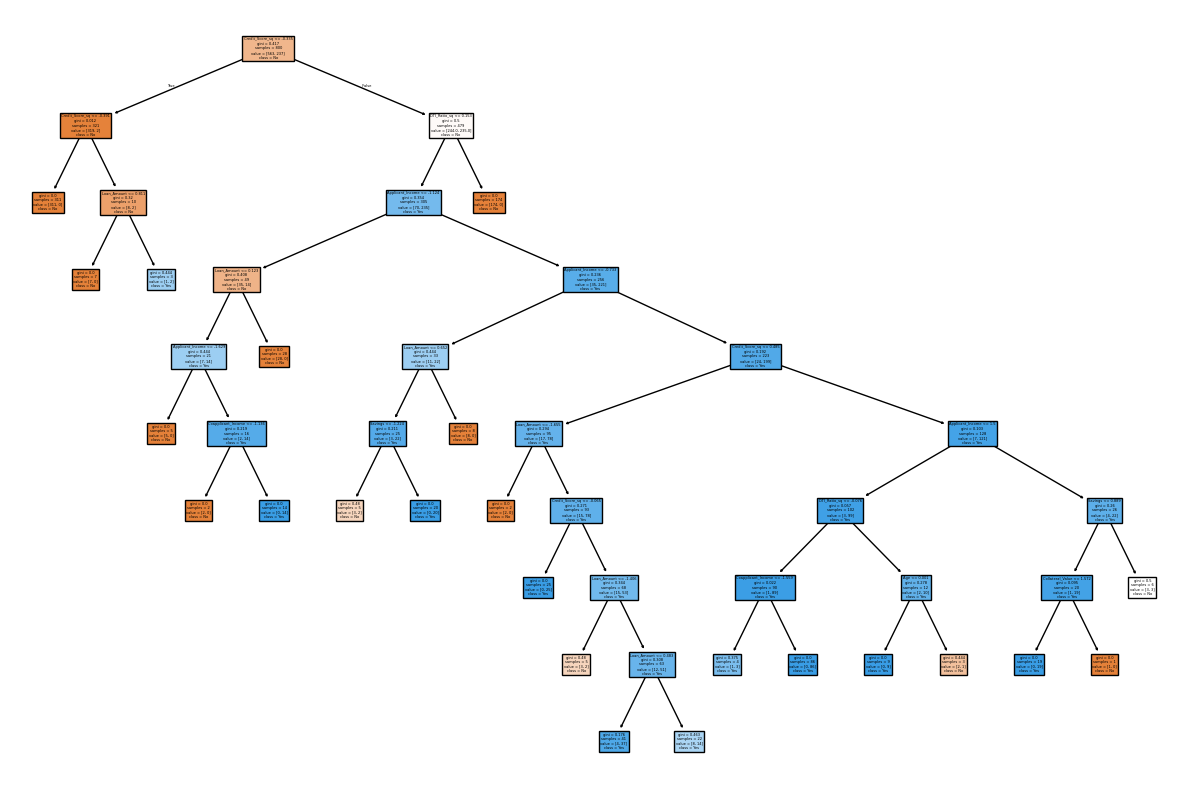

In [45]:
# Plot Tree
from sklearn.tree import plot_tree

plt.figure(figsize = (12, 8))

plot_tree(
    dt_model,
    feature_names = X.columns,
    class_names = ["No", "Yes"],
    filled = True
)

plt.tight_layout()
plt.show()

In [36]:
# HyperParameter Tuning for max_depth & min_samples_split
from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth": [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13],
    "min_samples_split": [5, 10, 15, 20, 25, 30, 35, 40]
}

dtc = DecisionTreeClassifier()

grid_search = GridSearchCV(
    dtc,
    param_grid,
    scoring = "f1",
    cv = 5
)

grid_search.fit(X_train_scaled, y_train)

print("Best Parameters :", grid_search.best_params_)

Best Parameters : {'max_depth': 5, 'min_samples_split': 10}


In [37]:
# Support Vector Machine (SVM) Classifier
from sklearn.svm import SVC

svc_model = SVC(C = 3, kernel = "rbf")
svc_model.fit(X_train_scaled, y_train)

y_pred = svc_model.predict(X_test_scaled)

print("SVM Classifier Model :")
print("Precision : ", precision_score(y_test, y_pred))
print("Recall : ", recall_score(y_test, y_pred))
print("F1 Score : ", f1_score(y_test, y_pred))
print("Accuracy : ", accuracy_score(y_test, y_pred))
print("CM : ", confusion_matrix(y_test, y_pred))

SVM Classifier Model :
Precision :  0.8035714285714286
Recall :  0.7377049180327869
F1 Score :  0.7692307692307693
Accuracy :  0.865
CM :  [[128  11]
 [ 16  45]]


In [38]:
# HyperParameter Tuning for max_depth & min_samples_split

param_grid = {
    "C": [0.1, 0.5, 1, 2, 3, 5, 10, 50, 100],
    "kernel": ["linear", "poly", "rbf", "sigmoid"]
}

svc = SVC()

grid_search = GridSearchCV(
    svc,
    param_grid,
    scoring = "f1",
    cv = 5
)

grid_search.fit(X_train_scaled, y_train)

print("Best Parameters :", grid_search.best_params_)

Best Parameters : {'C': 3, 'kernel': 'rbf'}


# Best Model ==> Decision Trees Classifier 

## Precision = 83%
## Accuracy = 91%